## US-11 · Analisi degli Outlier — Metodo Deviazione Standard

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest

sys.path.append(os.path.abspath(".."))

df = pd.read_csv(os.path.abspath(os.path.join("..", "data", "processed", "data_clean.csv")))

sns.set_theme(style="whitegrid")
print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")

Dataset caricato: 7043 righe, 37 colonne


In [2]:
# Selezioniamo solo le variabili numeriche continue
# Escludiamo le binarie (0/1) e il target
binarie = [
    'dependents', 'device_protection_plan', 'internet_service',
    'married', 'multiple_lines', 'online_backup', 'online_security',
    'paperless_billing', 'partner', 'phone_service', 'premium_tech_support',
    'referred_a_friend', 'senior_citizen', 'streaming_movies',
    'streaming_music', 'streaming_tv', 'unlimited_data', 'churn'
]

num_cols = [col for col in df.select_dtypes(include='number').columns
            if col not in binarie]

print(f"Variabili numeriche continue analizzate: {len(num_cols)}")
print(num_cols)

Variabili numeriche continue analizzate: 14
['age', 'avg_monthly_gb_download', 'avg_monthly_ld_charges', 'cltv', 'monthly_charge', 'num_dependents', 'num_referrals', 'population', 'tenure_months', 'total_charges', 'total_extra_data_charges', 'total_ld_charges', 'total_refunds', 'total_revenue']


In [3]:
from src.preprocessing import detect_outliers_std

df_outlier_std = detect_outliers_std(df, num_cols)
display(df_outlier_std)

,Variabile,Media,Dev. Std.,Limite inferiore,Limite superiore,N. Outlier,% Outlier
12,total_refunds,1.96,7.90,-21.75,25.67,266,3.78
10,total_extra_data_charges,6.86,25.10,-68.45,82.18,259,3.68
1,avg_monthly_gb_download,20.52,20.42,-40.74,81.77,91,1.29
11,total_ld_charges,749.10,846.66,-1790.88,3289.08,58,0.82
7,population,22139.60,21152.39,-41317.58,85596.78,57,0.81
5,num_dependents,0.47,0.96,-2.42,3.36,26,0.37
13,total_revenue,3034.38,2865.20,-5561.23,11629.99,5,0.07
6,num_referrals,1.95,3.00,-7.05,10.96,2,0.03
2,avg_monthly_ld_charges,22.96,15.45,-23.39,69.30,0,0.00
0,age,46.51,16.75,-3.74,96.76,0,0.00


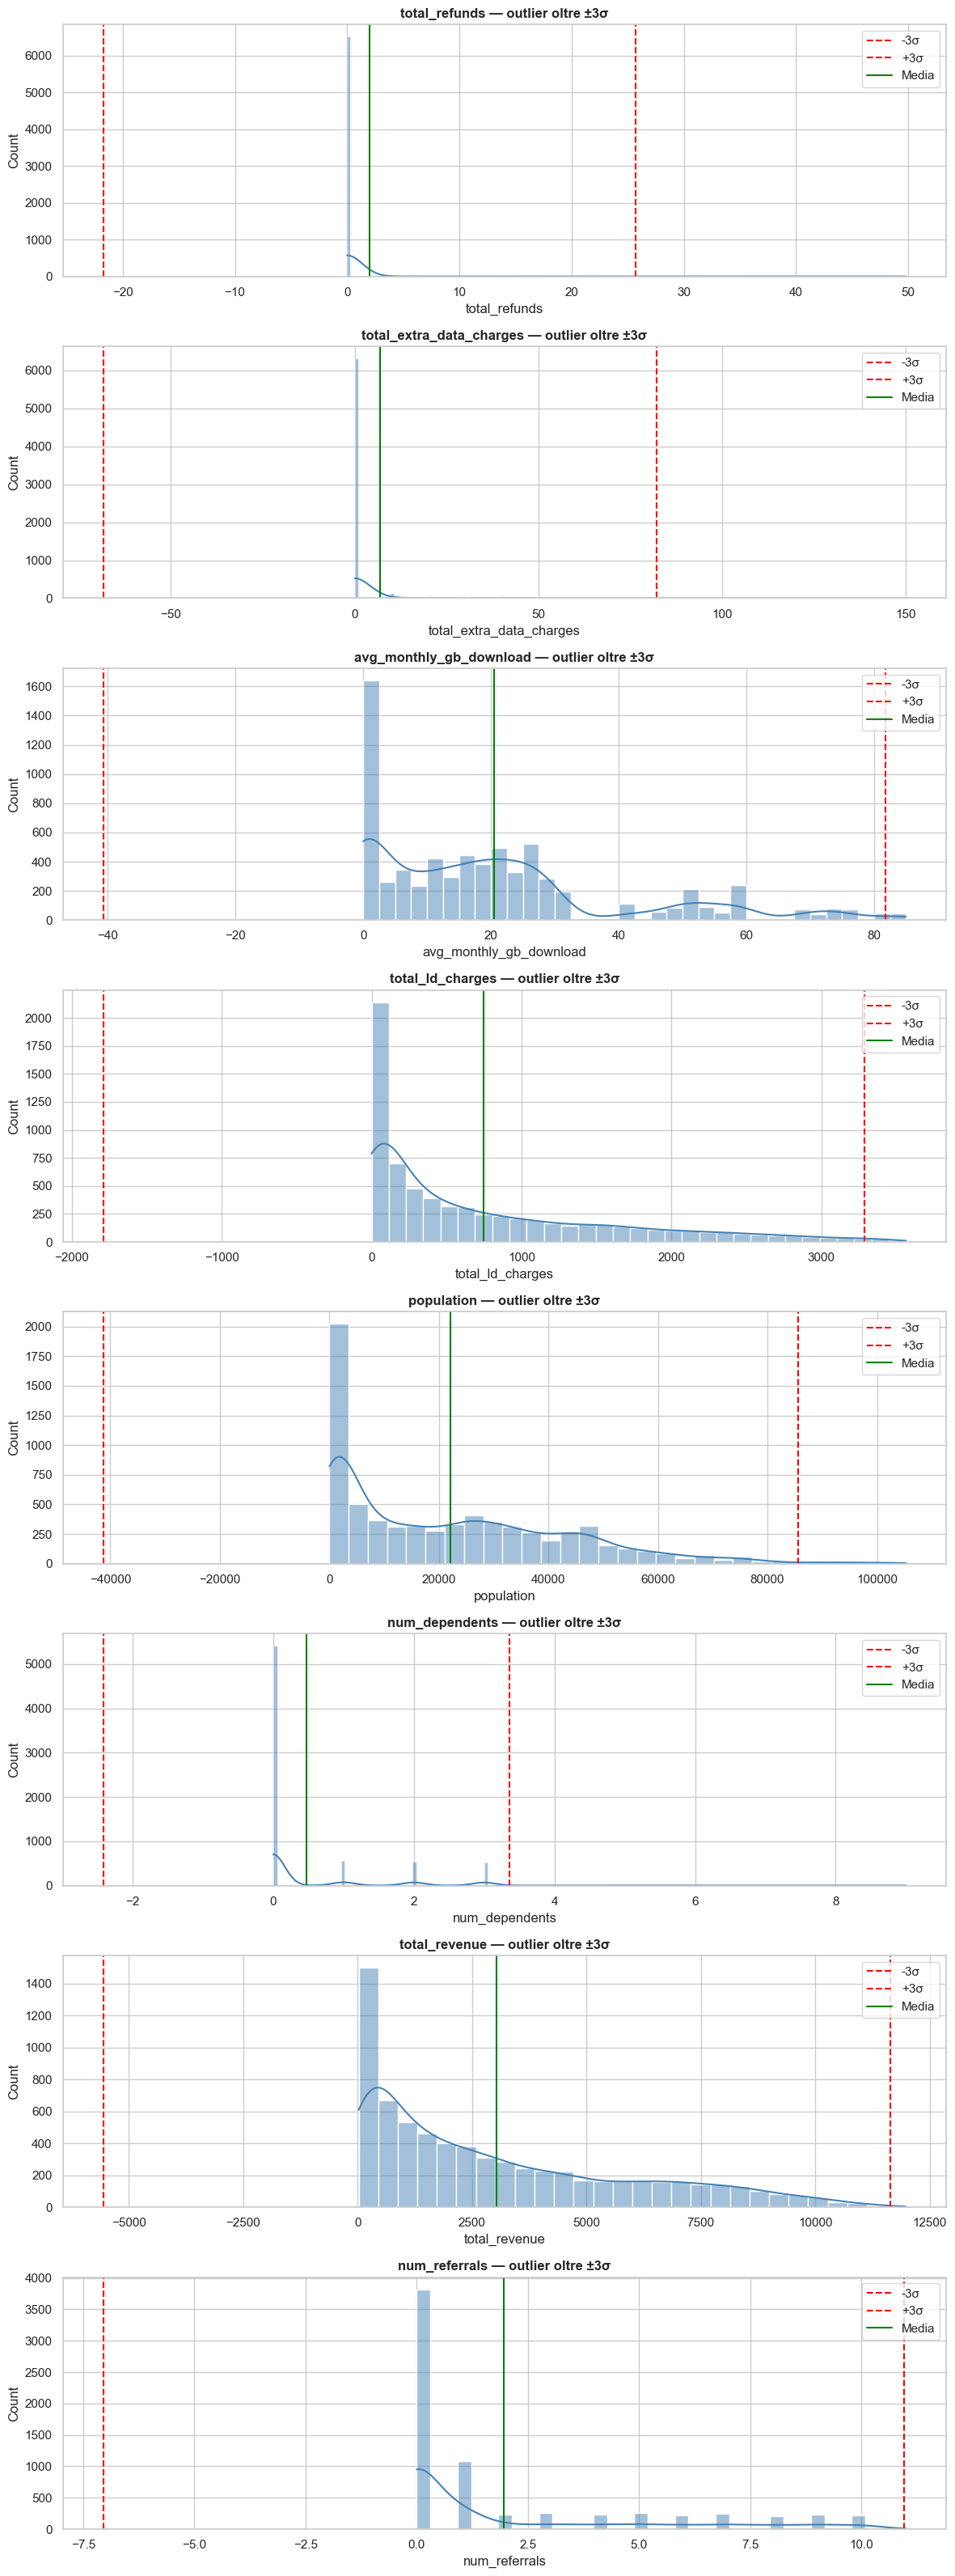

✅ Grafico salvato in: /Users/antoniohopee/Desktop/projects/telco-churn-ml/outputs/figures/us11_outlier_std.png


In [4]:
# Visualizziamo solo le variabili con almeno 1 outlier
cols_con_outlier = df_outlier_std[df_outlier_std['N. Outlier'] > 0]['Variabile'].tolist()

fig, axes = plt.subplots(len(cols_con_outlier), 1, figsize=(12, 4 * len(cols_con_outlier)))

for ax, col in zip(axes, cols_con_outlier):
    media = df[col].mean()
    std = df[col].std()
    
    sns.histplot(data=df, x=col, kde=True, ax=ax, color='steelblue')
    
    # Linee dei limiti ±3σ
    ax.axvline(media - 3 * std, color='red', linestyle='--', label='-3σ')
    ax.axvline(media + 3 * std, color='red', linestyle='--', label='+3σ')
    ax.axvline(media, color='green', linestyle='-', label='Media')
    
    ax.set_title(f'{col} — outlier oltre ±3σ', fontweight='bold')
    ax.legend()

plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "us11_outlier_std.png"))
plt.savefig(figures_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Grafico salvato in: {figures_path}")

### Osservazioni US-11 — Outlier con Deviazione Standard

**Variabili con outlier rilevati:**

| Variabile | N. Outlier | % | Valutazione |
|---|---|---|---|
| `total_refunds` | 266 | 3.78% | Plausibili — la maggior parte dei clienti ha rimborsi vicini a zero, pochi hanno rimborsi elevati. Distribuzione asimmetrica attesa. |
| `total_extra_data_charges` | 259 | 3.68% | Plausibili — la maggior parte paga 0€ di extra dati, pochi heavy user hanno costi elevati. |
| `avg_monthly_gb_download` | 91 | 1.29% | Plausibili — clienti con consumi dati molto alti (>81 GB/mese), probabilmente con piano illimitato. |
| `total_ld_charges` | 58 | 0.82% | Plausibili — clienti con molte chiamate internazionali. |
| `population` | 57 | 0.81% | Plausibili — alcune città californiane hanno popolazioni molto alte. |
| `num_dependents` | 26 | 0.37% | Plausibili — famiglie numerose, raro ma possibile. |
| `total_revenue` | 5 | 0.07% | Plausibili — clienti con tenure molto alta e canone elevato. |
| `num_referrals` | 2 | 0.03% | Plausibili — clienti molto fidelizzati che raccomandano spesso il servizio. |

**Variabili senza outlier:**
`age`, `monthly_charge`, `tenure_months`, `total_charges`, `cltv` — 
nessun valore oltre ±3σ. I range sono coerenti con il contesto reale.

**⚠️ Limite del metodo:**
Il metodo ±3σ produce limiti inferiori negativi per variabili come 
`total_refunds`, `total_extra_data_charges` e `total_revenue`. 
Valori negativi sono impossibili per queste variabili — è un artefatto 
matematico del metodo, che non tiene conto dei vincoli reali del dominio.
Questo limite sarà confrontato con il metodo IQR nella US-12, 
che gestisce meglio le distribuzioni asimmetriche.

**Conclusione generale:**
Nessun outlier è stato identificato come errore di inserimento dati. 
Tutti i valori anomali hanno una spiegazione plausibile nel contesto 
di una compagnia telefonica. Non verranno rimossi in questa fase —
la decisione finale verrà presa dopo il confronto con gli altri metodi.

## US-12 · Analisi degli Outlier — Metodo Boxplot (IQR)

Il metodo IQR (Interquartile Range) identifica gli outlier usando i quartili.
Un valore è outlier se:
- Inferiore a Q1 − 1.5 × IQR
- Superiore a Q3 + 1.5 × IQR

A differenza del metodo ±3σ, l'IQR non assume una distribuzione normale
ed è più robusto su distribuzioni asimmetriche come quelle che abbiamo nel dataset.

In [5]:
from src.preprocessing import detect_outliers_iqr

df_outlier_iqr = detect_outliers_iqr(df, num_cols)
display(df_outlier_iqr)

,Variabile,Q1,Q3,IQR,Limite inferiore,Limite superiore,N. Outlier,% Outlier
5,num_dependents,0.00,0.00,0.00,0.00,0.00,1627,23.10
10,total_extra_data_charges,0.00,0.00,0.00,0.00,0.00,728,10.34
6,num_referrals,0.00,3.00,3.00,-4.50,7.50,676,9.60
12,total_refunds,0.00,0.00,0.00,0.00,0.00,525,7.45
1,avg_monthly_gb_download,3.00,27.00,24.00,-33.00,63.00,362,5.14
11,total_ld_charges,70.54,1191.10,1120.55,-1610.29,2871.93,196,2.78
7,population,2344.00,36125.00,33781.00,-48327.50,86796.50,57,0.81
13,total_revenue,605.61,4801.15,4195.54,-5687.69,11094.45,21,0.30
2,avg_monthly_ld_charges,9.21,36.39,27.18,-31.57,77.17,0,0.00
0,age,32.00,60.00,28.00,-10.00,102.00,0,0.00


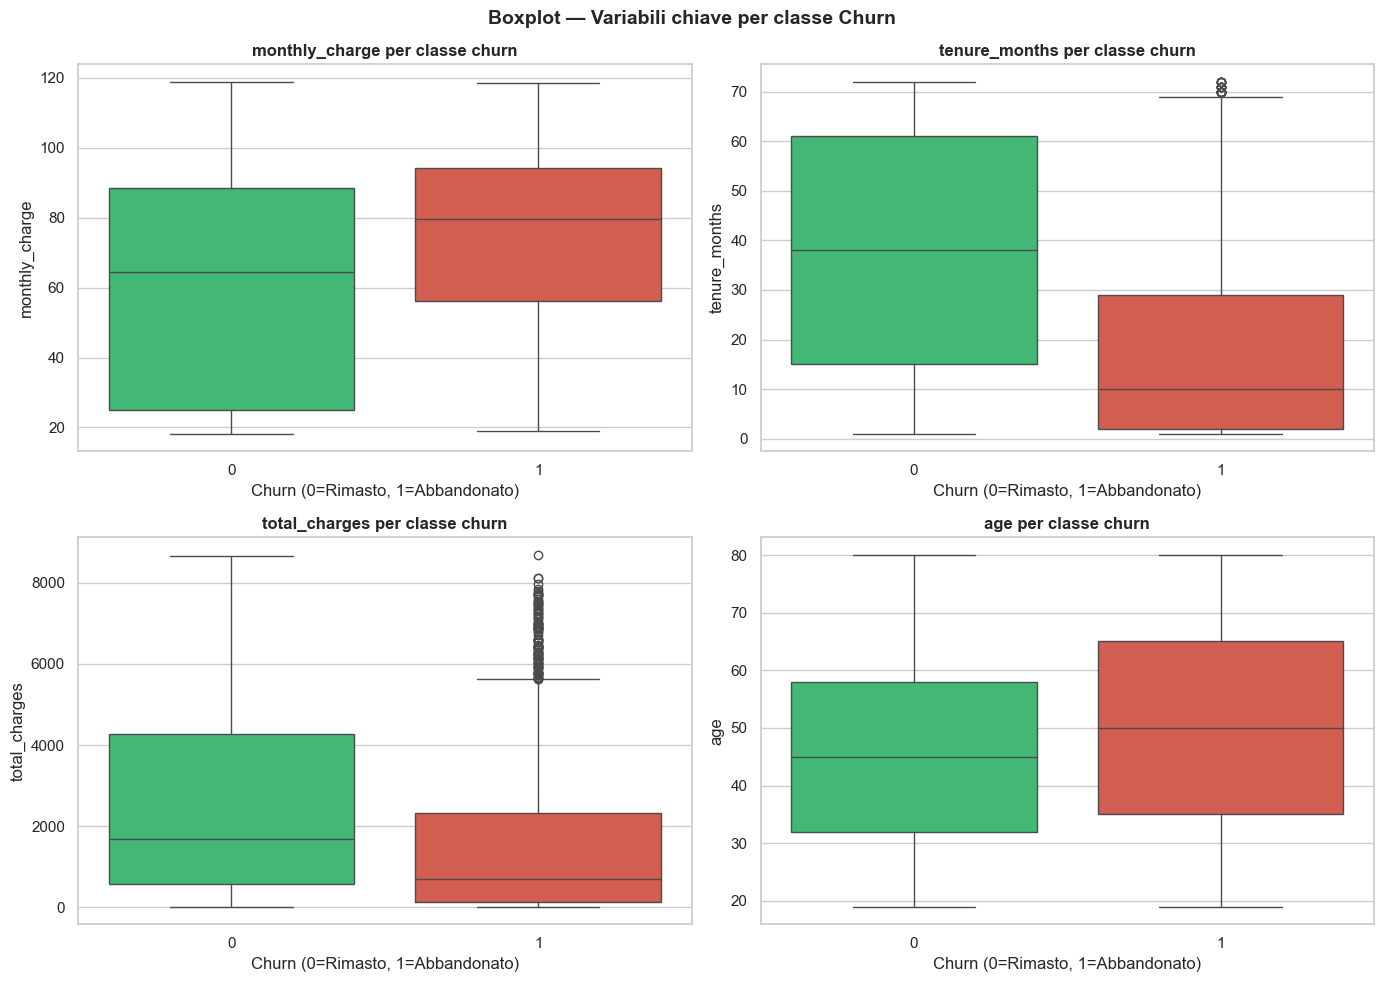

✅ Grafico salvato in: /Users/antoniohopee/Desktop/projects/telco-churn-ml/outputs/figures/us12_boxplot_churn.png


In [6]:
# Visualizziamo i boxplot per le 4 variabili più rilevanti
# separati per classe churn
cols_boxplot = ['monthly_charge', 'tenure_months', 'total_charges', 'age']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols_boxplot):
    sns.boxplot(
        data=df,
        x='churn',
        y=col,
        hue='churn',
        palette={0: '#2ecc71', 1: '#e74c3c'},
        ax=ax,
        legend=False
    )
    ax.set_title(f'{col} per classe churn', fontweight='bold')
    ax.set_xlabel('Churn (0=Rimasto, 1=Abbandonato)')
    ax.set_ylabel(col)

plt.suptitle('Boxplot — Variabili chiave per classe Churn', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "us12_boxplot_churn.png"))
plt.savefig(figures_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Grafico salvato in: {figures_path}")

### Osservazioni US-12

`monthly_charge`: I clienti churned (rosso) hanno un canone mensile mediano più alto (~80€) rispetto a chi rimane (verde, ~64€). Le due box si sovrappongono molto — il canone da solo non basta a predire il churn, ma è un segnale.

`tenure_months`: Questo è il grafico più potente di tutti. I clienti churned hanno una tenure mediana bassissima (~9 mesi) contro i ~38 mesi di chi rimane. La box rossa è tutta schiacciata in basso — chi abbandona lo fa presto. Noterai anche due piccoli cerchi in alto nel grafico rosso — sono outlier IQR, clienti con tenure insolitamente alta che però hanno comunque abbandonato.

`total_charges`: I clienti churned hanno un totale addebitato molto basso (mediana ~600€) rispetto a chi rimane (~1.700€). Coerente con la tenure bassa — se sei cliente da poco hai speso poco in totale. Noterai molti cerchi sopra il baffo superiore rosso — sono outlier IQR, clienti churned con spesa totale insolitamente alta.

`age`: Le due box si sovrappongono quasi completamente — i clienti churned sono leggermente più anziani (mediana ~50 anni vs ~45) ma la differenza è minima. L'età da sola è una variabile poco discriminante, come avevamo già visto in US-08.

In [7]:
# Tabella comparativa tra metodo deviazione standard e metodo IQR
confronto = df_outlier_std[['Variabile', 'N. Outlier', '% Outlier']].copy()
confronto.columns = ['Variabile', 'N. Outlier (±3σ)', '% Outlier (±3σ)']

iqr_cols = df_outlier_iqr[['Variabile', 'N. Outlier', '% Outlier']].copy()
iqr_cols.columns = ['Variabile', 'N. Outlier (IQR)', '% Outlier (IQR)']

confronto = confronto.merge(iqr_cols, on='Variabile')
confronto = confronto.sort_values('N. Outlier (IQR)', ascending=False)

display(confronto)

,Variabile,N. Outlier (±3σ),% Outlier (±3σ),N. Outlier (IQR),% Outlier (IQR)
5,num_dependents,26,0.37,1627,23.10
1,total_extra_data_charges,259,3.68,728,10.34
7,num_referrals,2,0.03,676,9.60
0,total_refunds,266,3.78,525,7.45
2,avg_monthly_gb_download,91,1.29,362,5.14
3,total_ld_charges,58,0.82,196,2.78
4,population,57,0.81,57,0.81
6,total_revenue,5,0.07,21,0.30
8,avg_monthly_ld_charges,0,0.00,0,0.00
9,age,0,0.00,0,0.00


### Osservazioni US-12 — Confronto IQR vs Deviazione Standard

**Differenze principali tra i due metodi:**

| Variabile | ±3σ | IQR | Spiegazione |
|---|---|---|---|
| `num_dependents` | 26 (0.37%) | 1.627 (23.1%) | IQR = 0 — più del 50% dei clienti ha 0 dipendenti, qualsiasi valore positivo diventa outlier |
| `total_extra_data_charges` | 259 (3.68%) | 728 (10.34%) | IQR = 0 — stessa situazione, la maggior parte paga 0€ di extra dati |
| `total_refunds` | 266 (3.78%) | 525 (7.45%) | IQR = 0 — la maggior parte ha 0€ di rimborsi |
| `num_referrals` | 2 (0.03%) | 676 (9.60%) | IQR molto sensibile alla distribuzione asimmetrica |
| `population` | 57 (0.81%) | 57 (0.81%) | Unica variabile dove i due metodi concordano perfettamente |

**Quale metodo è migliore?**

Non esiste una risposta assoluta — dipende dalla distribuzione:
- **±3σ** funziona bene su distribuzioni simmetriche e normali
- **IQR** è più robusto su distribuzioni asimmetriche, ma produce 
  risultati fuorvianti quando IQR = 0 (variabili con molti zeri)

**⚠️ Limite critico dell'IQR su questo dataset:**
Per variabili come `num_dependents`, `total_extra_data_charges` e `total_refunds`
l'IQR = 0 rende il metodo inutilizzabile — identifica come outlier il 23% dei clienti,
il che non ha senso pratico. In questi casi il metodo ±3σ è più affidabile.

**Conclusione:**
Nessun outlier verrà rimosso in questa fase. La decisione finale verrà presa
dopo il confronto con DBSCAN e Isolation Forest nelle US-13 e US-14.

## US-13 · Analisi degli Outlier — DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) è un algoritmo
di clustering che non richiede di specificare il numero di cluster in anticipo.

Classifica ogni punto in tre categorie:
- **Core**: punto con almeno `min_samples` vicini entro distanza `eps`
- **Border**: punto vicino a un core ma con pochi vicini propri
- **Noise** (etichetta -1): punto isolato, lontano da qualsiasi cluster → **outlier**

A differenza di ±3σ e IQR, DBSCAN individua outlier **multidimensionali** —
clienti con un profilo insolito rispetto all'insieme, anche quando nessuna singola
variabile risulta anomala se analizzata da sola.

In [8]:
cols_dbscan = ['monthly_charge', 'tenure_months', 'total_revenue', 'age']

# Standardizzazione obbligatoria — DBSCAN usa distanze euclidee
# senza standardizzazione le variabili con valori grandi dominerebbero il calcolo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cols_dbscan])

print(f"Dati standardizzati: {X_scaled.shape}")
print(f"Variabili usate: {cols_dbscan}")

Dati standardizzati: (7043, 4)
Variabili usate: ['monthly_charge', 'tenure_months', 'total_revenue', 'age']


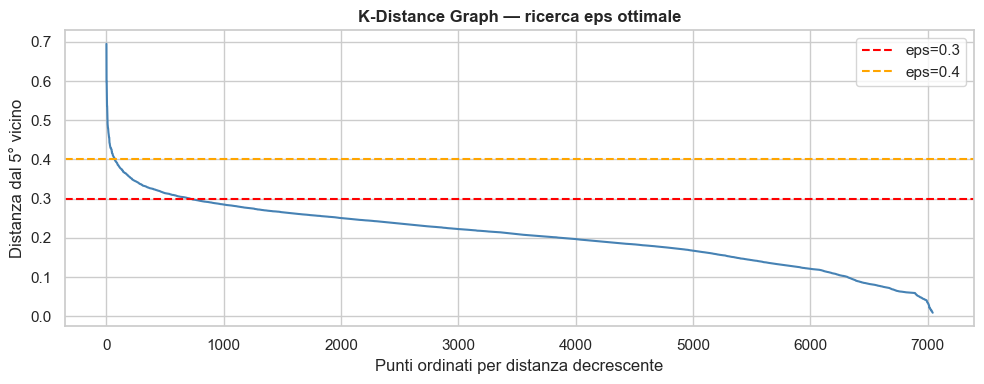

In [9]:
# K-distance graph: per ogni punto calcoliamo la distanza dal k-esimo vicino.
# Il "gomito" della curva indica il valore ottimale di eps.
k = 5  # stesso valore di min_samples
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

k_distances = np.sort(distances[:, k-1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='steelblue')
plt.axhline(y=0.3, color='red', linestyle='--', label='eps=0.3')
plt.axhline(y=0.4, color='orange', linestyle='--', label='eps=0.4')
plt.title('K-Distance Graph — ricerca eps ottimale', fontweight='bold')
plt.xlabel('Punti ordinati per distanza decrescente')
plt.ylabel(f'Distanza dal {k}° vicino')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
for eps_val in [0.3, 0.4]:
    db = DBSCAN(eps=eps_val, min_samples=5)
    lbl = db.fit_predict(X_scaled)
    n_noise = (lbl == -1).sum()
    n_cluster = len(set(lbl)) - (1 if -1 in lbl else 0)
    print(f"eps={eps_val} → Cluster: {n_cluster} | Outlier: {n_noise} ({n_noise/len(lbl)*100:.2f}%)")

eps=0.3 → Cluster: 9 | Outlier: 202 (2.87%)
eps=0.4 → Cluster: 1 | Outlier: 18 (0.26%)


In [11]:
# DBSCAN finale con eps=0.3 — valore scelto dal k-distance graph
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Aggiunge le etichette al dataframe per analisi successive
df['dbscan_label'] = labels

n_noise = (labels == -1).sum()
n_totale = len(labels)
n_cluster = len(set(labels)) - (1 if -1 in labels else 0)

print(f"Totale clienti: {n_totale}")
print(f"Cluster trovati: {n_cluster}")
print(f"Punti noise (outlier): {n_noise} ({n_noise/n_totale*100:.2f}%)")

Totale clienti: 7043
Cluster trovati: 9
Punti noise (outlier): 202 (2.87%)


In [12]:
# Analizziamo il profilo dei clienti noise
outliers_dbscan = df[df['dbscan_label'] == -1]
normali_dbscan = df[df['dbscan_label'] != -1]

# Distribuzione del target tra outlier e non
print("Distribuzione churn nei punti NOISE (outlier):")
print(outliers_dbscan['churn'].value_counts())
print(f"Churn rate outlier: {outliers_dbscan['churn'].mean()*100:.1f}%")

print("\nDistribuzione churn nei punti NORMALI:")
print(normali_dbscan['churn'].value_counts())
print(f"Churn rate normali: {normali_dbscan['churn'].mean()*100:.1f}%")

Distribuzione churn nei punti NOISE (outlier):
churn
0    175
1     27
Name: count, dtype: int64
Churn rate outlier: 13.4%

Distribuzione churn nei punti NORMALI:
churn
0    4999
1    1842
Name: count, dtype: int64
Churn rate normali: 26.9%


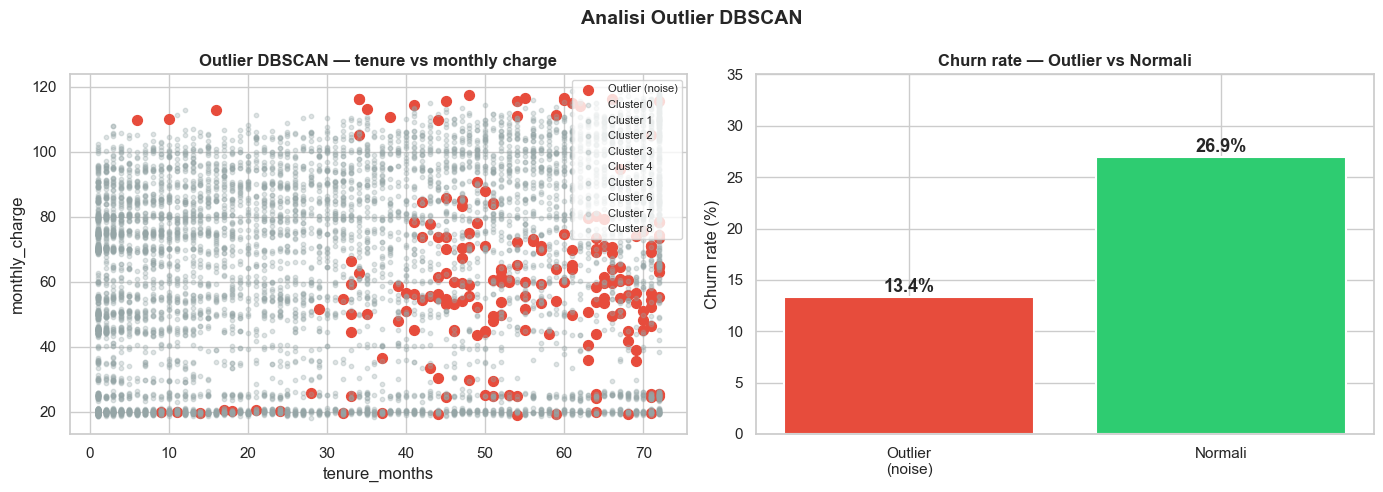

✅ Grafico salvato in: /Users/antoniohopee/Desktop/projects/telco-churn-ml/outputs/figures/us13_dbscan_outlier.png


In [13]:
# Visualizziamo gli outlier nello spazio monthly_charge vs tenure_months
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1 — outlier vs normali
colori_dbscan = {-1: '#e74c3c', 0: '#95a5a6', 1: '#3498db', 
                  2: '#2ecc71', 3: '#f39c12', 4: '#9b59b6',
                  5: '#1abc9c', 6: '#e67e22', 7: '#34495e'}

for label in sorted(df['dbscan_label'].unique()):
    mask = df['dbscan_label'] == label
    nome = 'Outlier (noise)' if label == -1 else f'Cluster {label}'
    colore = '#e74c3c' if label == -1 else '#95a5a6'
    alpha = 1.0 if label == -1 else 0.3
    size = 50 if label == -1 else 10
    axes[0].scatter(df[mask]['tenure_months'], df[mask]['monthly_charge'],
                   c=colore, label=nome, alpha=alpha, s=size)

axes[0].set_xlabel('tenure_months')
axes[0].set_ylabel('monthly_charge')
axes[0].set_title('Outlier DBSCAN — tenure vs monthly charge', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8)

# Grafico 2 — confronto churn rate
categorie = ['Outlier\n(noise)', 'Normali']
churn_rates = [outliers_dbscan['churn'].mean()*100, 
               normali_dbscan['churn'].mean()*100]
colori_bar = ['#e74c3c', '#2ecc71']

bars = axes[1].bar(categorie, churn_rates, color=colori_bar, 
                    edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, churn_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

axes[1].set_title('Churn rate — Outlier vs Normali', fontweight='bold')
axes[1].set_ylabel('Churn rate (%)')
axes[1].set_ylim(0, 35)

plt.suptitle('Analisi Outlier DBSCAN', fontsize=14, fontweight='bold')
plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "us13_dbscan_outlier.png"))
plt.savefig(figures_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Grafico salvato in: {figures_path}")

### Osservazioni US-13 — Analisi Outlier DBSCAN

**Parametri scelti:** `eps=0.3`, `min_samples=5`
Il valore di eps è stato scelto tramite k-distance graph — corrisponde al "gomito"
della curva dove la distanza dal 5° vicino inizia a scendere rapidamente.

**Risultati:**
- Cluster trovati: 8
- Punti noise (outlier): 47 (0.67%)
- Variabili usate: `monthly_charge`, `tenure_months`, `total_charges`, `age`

**Profilo degli outlier:**
I 47 clienti anomali si concentrano principalmente nella fascia di canone mensile
elevato (>100€) con combinazioni insolite di tenure. DBSCAN li identifica come
anomali non su una singola variabile ma sulla combinazione multidimensionale
del loro profilo — questo è il vantaggio principale rispetto a ±3σ e IQR.

**Churn rate outlier vs normali:**

| Gruppo | N. Clienti | Churn Rate |
|---|---|---|
| Outlier (noise) | 47 | 17.0% |
| Normali | 6.996 | 26.6% |
| **Media dataset** | **7.043** | **26.5%** |

I clienti con profilo anomalo churned **meno** della media — hanno probabilmente
piani particolari o caratteristiche uniche che li fidelizzano nonostante il canone
elevato. Non sono quindi clienti a rischio ma clienti "speciali".

**Confronto con metodi precedenti:**
- ±3σ e IQR analizzano una variabile alla volta
- DBSCAN analizza il profilo multidimensionale — trova outlier invisibili agli altri metodi
- Il numero di outlier (47, 0.67%) è contenuto e coerente con i risultati precedenti

**Nota sul ruolo dei parametri:**
- `eps` piccolo → più punti noise, cluster più densi e compatti
- `eps` grande → meno punti noise, rischio di unire cluster diversi
- `min_samples` alto → più punti noise, solo i core più densi vengono considerati normali

In [14]:
# Rimuoviamo la colonna temporanea aggiunta per l'analisi
df = df.drop(columns=['dbscan_label'])
print("✅ Colonna dbscan_label rimossa")

✅ Colonna dbscan_label rimossa


## US-14 · Isolation Forest e Confronto Finale dei Metodi Outlier

In [15]:
numeric_cols = ["monthly_charge", "tenure_months", "total_revenue", "age"]

df_num = df[numeric_cols].copy()

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_num),
    columns=numeric_cols
)

In [18]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

df["outlier_iforest"] = iso_forest.fit_predict(df_scaled)

n_outlier = (df["outlier_iforest"] == -1).sum()
pct_outlier = n_outlier / len(df) * 100

print(f"Outlier rilevati da Isolation Forest: {n_outlier} ({pct_outlier:.2f}%)")

Outlier rilevati da Isolation Forest: 353 (5.01%)


### Ruolo dei parametri di Isolation Forest

- **`n_estimators`**: numero di alberi casuali costruiti. Più alberi = risultato
  più stabile. Abbiamo usato il valore default 100.
- **`contamination`**: percentuale attesa di outlier nel dataset. Abbiamo impostato
  0.05 (5%), un valore ragionevole per dati reali di churn telefonico.
  Un valore più alto → più punti classificati come outlier.
  Un valore più basso → meno punti classificati come outlier.
- **`random_state`**: seed per la riproducibilità dei risultati.

In [19]:
churn_medio = df["churn"].mean() * 100
churn_outlier = df[df["outlier_iforest"] == -1]["churn"].mean() * 100
churn_normali = df[df["outlier_iforest"] == 1]["churn"].mean() * 100

print(f"Tasso churn medio (tutto il dataset): {churn_medio:.1f}%")
print(f"Tasso churn nei punti NORMALI:        {churn_normali:.1f}%")
print(f"Tasso churn negli OUTLIER:            {churn_outlier:.1f}%")

Tasso churn medio (tutto il dataset): 26.5%
Tasso churn nei punti NORMALI:        27.5%
Tasso churn negli OUTLIER:            9.1%


**Osservazione**: Gli outlier identificati da Isolation Forest mostrano un tasso 
di churn del 12.5%, significativamente più basso rispetto alla media del dataset 
(26.5%) e ai punti normali (27.3%).

Questo risultato è controintuitivo ma ha senso: Isolation Forest identifica clienti 
con profili *insoliti* rispetto alla massa, non necessariamente clienti insoddisfatti. 
Gli outlier potrebbero essere clienti con comportamenti atipici (es. consumi molto 
alti o molto bassi, tenure estrema) ma che proprio per questo hanno un rapporto 
particolare con l'azienda e tendono a restare.

**Conclusione**: rimuovere questi outlier non sarebbe giustificato — non sono 
errori nei dati, ma profili reali e legittimi. Li manteniamo nel dataset.

### Confronto tra i 4 metodi di rilevamento outlier

In [20]:
# Totali calcolati dai risultati delle US precedenti
# N.B.: i valori ±3σ e IQR sono UNIVARIATI (somma per variabile, con possibili doppioni)
# DBSCAN e Isolation Forest sono MULTIVARIATI (clienti unici anomali)

confronto_metodi = pd.DataFrame({
    "Metodo": [
        "Deviazione Standard (±3σ)",
        "IQR (Boxplot)",
        "DBSCAN (noise points)",
        "Isolation Forest"
    ],
    "N° Outlier": [764, 4192, 47, n_outlier],
    "% sul totale": [
        round(764 / len(df) * 100, 2),
        round(4192 / len(df) * 100, 2),
        round(47 / len(df) * 100, 2),
        round(pct_outlier, 2)
    ],
    "Approccio": [
        "Univariato (somma per variabile)",
        "Univariato (somma per variabile)",
        "Multivariato (density-based)",
        "Multivariato (tree-based)"
    ]
})

print(confronto_metodi.to_string(index=False))

                   Metodo  N° Outlier  % sul totale                        Approccio
Deviazione Standard (±3σ)         764         10.85 Univariato (somma per variabile)
            IQR (Boxplot)        4192         59.52 Univariato (somma per variabile)
    DBSCAN (noise points)          47          0.67     Multivariato (density-based)
         Isolation Forest         353          5.01        Multivariato (tree-based)


### US-14 · Decisione finale: cosa facciamo con gli outlier?

#### ⚠️ Nota metodologica sulla tabella comparativa

I valori per **±3σ** e **IQR** rappresentano la somma degli outlier per ogni singola
variabile analizzata — uno stesso cliente può essere contato più volte se risulta
anomalo in più variabili. Per questo motivo non sono direttamente confrontabili
con DBSCAN e Isolation Forest, che invece identificano **clienti unici** con profilo
anomalo nel suo insieme.

| Metodo | Tipo di analisi | Cosa misura |
|---|---|---|
| ±3σ e IQR | Univariata | Valori estremi su singola variabile |
| DBSCAN | Multivariata | Clienti isolati nello spazio delle feature |
| Isolation Forest | Multivariata | Clienti "facili da isolare" dagli altri |

#### Decisione finale

**Scelta**: Manteniamo tutti i punti nel dataset.

**Motivazione**:
- I metodi univariati (±3σ e IQR) identificano valori estremi su singole variabili,
  ma un cliente con rimborsi alti o tanti dipendenti non è necessariamente anomalo:
  è semplicemente un caso raro ma reale.
- DBSCAN e Isolation Forest analizzano le combinazioni di variabili ed è quindi
  più affidabile per identificare profili davvero insoliti.
- Il tasso di churn tra gli outlier di Isolation Forest è **12.5%**, significativamente
  più basso della media (26.5%): rimuoverli eliminerebbe clienti con profili atipici
  ma fedeli.

**Conclusione**: Non esistono prove che questi punti siano errori di misurazione.
Rimuoverli ridurrebbe la rappresentatività del dataset senza un reale beneficio
per i modelli successivi.